In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely
import pandas as pd
from geodatasets import get_path
import ast
# import geopy.distances
from tqdm import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from sklearn.model_selection import ShuffleSplit, KFold
from scipy.stats import zscore
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import ListedColormap
sys.path.append('../src/')
sys.path.append('../content/')
import data_utils as du
import vis_utils as vu
import sample_locations as sl

## Set `data_folder` and plot example:

In [10]:
## Set data folder to the parent folder with the subfolders for each modality (e.g. alphaearth, dynamicworld, tessera):
data_folder = '/Users/tplas/data/dw_sampled_locations/data_spherical/'

list_ids, modality_folders, gdf_points = du.get_list_complete_ids(data_folder)
print(f'Number of samples: {len(list_ids)}')
countries = gpd.read_file('/Users/tplas/data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')


Sample random_sample has 9695 data points out of 18393.
Sample lc_stratified_sample has 9693 data points out of 18393.
Number of samples: 18393


Sample random_sample has 9695 data points out of 18393.
Sample lc_stratified_sample has 9693 data points out of 18393.


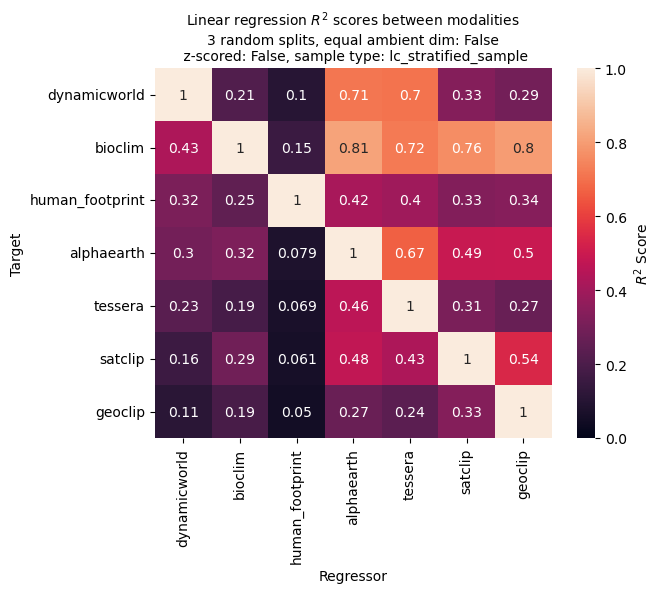

In [134]:
## regression:

def get_r2_regression(df_all, col_names, regressor, target, n_splits=4, equalize_ambient_dim=False):
    df_all = df_all.copy()
    data_regressor = df_all[col_names[regressor]].values
    data_target = df_all[col_names[target]].values
    assert data_regressor.shape[0] == data_target.shape[0]
    if equalize_ambient_dim and regressor != 'dynamicworld' and target != 'dynamicworld':
        if data_regressor.shape[1] > data_target.shape[1]:
            pca = PCA(n_components=data_target.shape[1])
            data_regressor = pca.fit_transform(data_regressor)
        elif data_target.shape[1] > data_regressor.shape[1]:
            pca = PCA(n_components=data_regressor.shape[1])
            data_target = pca.fit_transform(data_target)
        

    if n_splits > 1:
        rs = KFold(n_splits=n_splits, shuffle=True, random_state=0)
        mse_per_point = np.zeros(len(df_all))
        r2 = np.zeros(n_splits)
        Y_pred = np.zeros_like(data_target)
        for i, (train_index, test_index) in enumerate(rs.split(df_all)):
            
            X_train = data_regressor[train_index]
            Y_train = data_target[train_index]
            X_test = data_regressor[test_index]
            Y_test = data_target[test_index]
        
            reg = LinearRegression().fit(X_train, Y_train)
            Y_pred[test_index] = reg.predict(X_test)
            # r2[i] = r2_score(Y_test, Y_pred)    ## TODO: first stack, then compute r2 once.
            mse_per_point[test_index] = np.mean((Y_test - Y_pred[test_index]) ** 2, axis=1)
        
    elif n_splits == 1:
        X = data_regressor
        Y = data_target
        reg = LinearRegression().fit(X, Y)
        Y_pred = reg.predict(X)
        mse_per_point = np.mean((Y - Y_pred) ** 2, axis=1)
    r2 = r2_score(data_target, Y_pred)
    residuals = data_target - Y_pred
    df_all[f'{regressor}_to_{target}_mse'] = mse_per_point
    return np.mean(r2), df_all, {'target': data_target, 'predictions': Y_pred, 'residuals': residuals}


n_splits = 3
save_plot = False

sample_type = 'lc_stratified_sample'
zscore_embeddings = False
pca_equalize_ambient_dim = False

# for sample_type in ['lc_stratified_sample', 'random_sample']:
#     for zscore_embeddings in [True, False]:
#         for pca_equalize_ambient_dim in [True, False]:

df_all, col_names = du.merge_modalities(parent_folder=data_folder, sample_type=sample_type, zscore_embeddings=zscore_embeddings)

ordering_cols = ['dynamicworld', 'bioclim', 'human_footprint', 'alphaearth', 'tessera', 'satclip', 'geoclip']
assert all([col in col_names for col in ordering_cols]), f"Not all ordering columns are in col_names. Missing: {[col for col in ordering_cols if col not in col_names]}"
assert all([col in ordering_cols for col in col_names]), f"Not all col_names are in ordering_cols. Missing: {[col for col in col_names if col not in ordering_cols]}"
col_names = {col: col_names[col] for col in ordering_cols}

mods = list(col_names.keys())
n_mod = len(mods)
r2_matrix = np.zeros((n_mod, n_mod))
for i, regressor in enumerate(mods):
    for j, target in enumerate(mods):
        r2_matrix[i, j], mse,_  = get_r2_regression(df_all, col_names, regressor, target, n_splits=n_splits,
        equalize_ambient_dim=pca_equalize_ambient_dim)

sns.heatmap(r2_matrix.T, xticklabels=mods, yticklabels=mods, annot=True, vmin=0, vmax=1,
            cbar_kws={'label': r"$R^2$" + ' Score'})
plt.xlabel('Regressor')
plt.ylabel('Target')
plt.title(f'Linear regression $R^2$ scores between modalities\n{n_splits} random splits, equal ambient dim: {pca_equalize_ambient_dim}\n z-scored: {zscore_embeddings}, sample type: {sample_type}', 
        fontsize=10)

if save_plot:
    plot_folder = '../figs/heatmap_explvar_modalities/'
    assert os.path.exists(plot_folder) and os.path.isdir(plot_folder), f"Plot folder {plot_folder} does not exist and/or is not a directory."
    fname = f'heatmap_r2_{sample_type}_zscore-{zscore_embeddings}_pca-{pca_equalize_ambient_dim}_splits-{n_splits}.pdf'
    plt.savefig(os.path.join(plot_folder, fname),bbox_inches='tight')

# plt.clf()
# plt.close()

Sample random_sample has 9695 data points out of 18393.
Sample lc_stratified_sample has 9693 data points out of 18393.


Text(0.5, 1.0, 'MSE of linear regression from geoclip to alphaearth\nrandom_sample sample, n_splits=3')

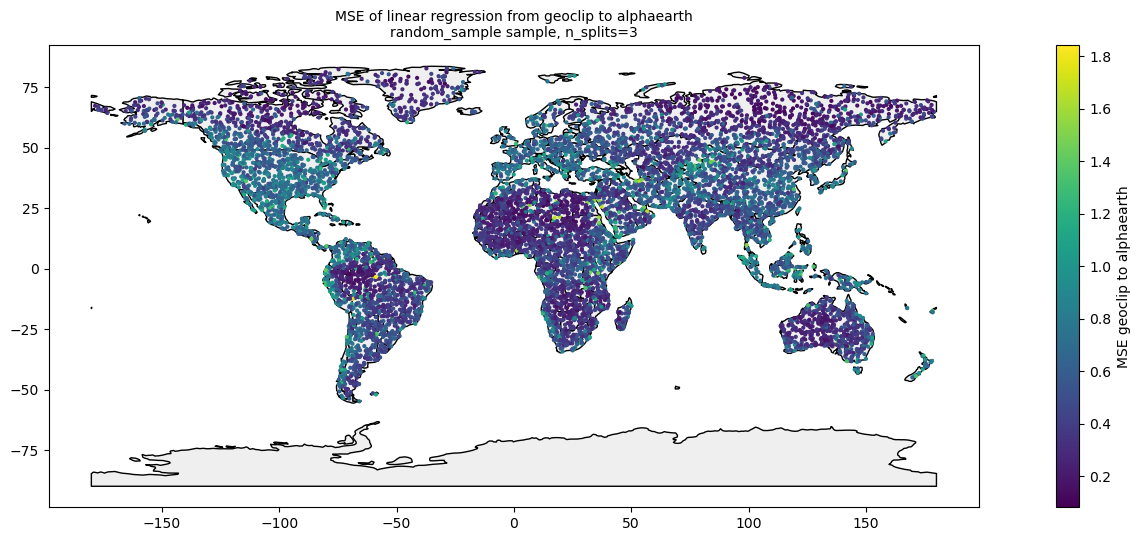

In [147]:
regressor = 'geoclip'
target = 'alphaearth'
sample_type = 'random_sample'

df_all, col_names = du.merge_modalities(parent_folder=data_folder, sample_type=sample_type, zscore_embeddings=True) 
r2, gdf_tmp, y_data = get_r2_regression(df_all, col_names, regressor, target, n_splits=3)
gdf_tmp = gpd.GeoDataFrame(gdf_tmp, geometry=gpd.points_from_xy(gdf_tmp['lon'], gdf_tmp['lat']), crs='EPSG:4326')
fig, ax = plt.subplots(figsize=(20,6))
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
gdf_tmp.plot(column=f'{regressor}_to_{target}_mse', cmap='viridis', legend=True, markersize=4, ax=ax,
             legend_kwds={'label': f'MSE {regressor} to {target}'})
plt.title(f'MSE of linear regression from {regressor} to {target}\n{sample_type} sample, n_splits=3', fontsize=10)

In [163]:
target = 'alphaearth'
sample_type = 'random_sample'
list_regressors = ['geoclip', 'satclip', 'tessera', 'human_footprint', 'bioclim', 'dynamicworld', 'all_geospatial']
list_colors = ['#77AADD', '#EE8866', '#EEDD88', '#FFAABB', '#99DDFF', '#44BB99', '#BBCC33', '#AAAA00']
colors = {r: list_colors[ii] for ii, r in enumerate(list_regressors)}

results = {'dim_residual': [], 'dim_target': [], 'dim_predictions': [], 'regressor': [], 'target': [], 'r2': []}
# df_all, col_names = du.merge_modalities(parent_folder=data_folder, sample_type=sample_type, zscore_embeddings=True)

for r in list_regressors:
    r2, gdf_tmp, y_data = get_r2_regression(df_all, col_names, r, target, n_splits=3)
    results['regressor'].append(r)
    results['r2'].append(r2)
    results['target'].append(target)

    results['dim_residual'].append(get_dim(y_data['residuals'])[0])
    results['dim_target'].append(get_dim(y_data['target'])[0])
    results['dim_predictions'].append(get_dim(y_data['predictions'])[0])

df_results_dim = pd.DataFrame(results)
df_results_dim = df_results_dim.sort_values('dim_predictions', ascending=False)
df_results_dim

,dim_residual,dim_target,dim_predictions,regressor,target,r2
2,40.073036,20.794031,12.927351,tessera,alphaearth,0.684731
0,34.194498,20.794031,10.698191,geoclip,alphaearth,0.492686
1,34.221497,20.794031,10.602464,satclip,alphaearth,0.485954
6,25.790560,20.794031,7.472782,all_geospatial,alphaearth,0.408433
4,25.989108,20.794031,5.274247,bioclim,alphaearth,0.300503
5,24.006097,20.794031,4.063094,dynamicworld,alphaearth,0.241675
3,21.654972,20.794031,1.605909,human_footprint,alphaearth,0.040440


Text(0.75, 1, 'Residual dim:')

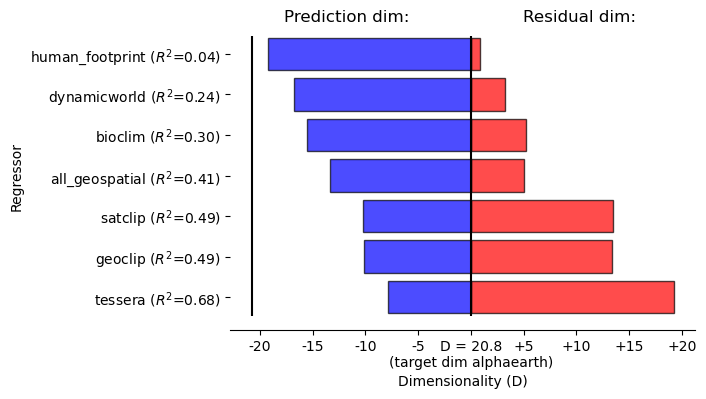

In [199]:

# heights = list(df_results_dim['dim_residual']) + [df_results_dim['dim_target'].iloc[0]] + list(df_results_dim['dim_predictions'])
# plt.bar(np.arange(len(heights)), heights)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(7)
target_dim = df_results_dim['dim_target'].iloc[0]
plt.barh(x, df_results_dim['dim_residual'] - target_dim , color='red', label='Residuals', alpha=0.7, edgecolor='black')
plt.barh(x, df_results_dim['dim_predictions'] - target_dim, color='blue', label='Predictions', alpha=0.7, edgecolor='black')

plt.vlines(0, -.45, 6.45, colors='black')
plt.vlines(-target_dim, -.45, 6.45, colors='black')

xticks = np.arange(-4, 5, 1) * 5
xticks_labels = list(xticks[:4]) + [f'D = {target_dim:.1f}\n(target dim {target})'] + [f'+{x}' for x in xticks[5:]]
ax.set_xticks(xticks)
ax.set_xticklabels(xticks_labels)
yticks = np.arange(len(df_results_dim))
ax.set_yticks(yticks)
yticklabels = [f"{row['regressor']} ($R^2$={row['r2']:.2f})" for _, row in df_results_dim.iterrows()]
ax.set_yticklabels(yticklabels)
for sp in ['top', 'right', 'left']:
    ax.spines[sp].set_visible(False)
ax.set_ylabel('Regressor')
ax.set_xlabel('Dimensionality (D)')
ax.annotate('Prediction dim:', xy=(0.25, 1), xycoords='axes fraction', ha='center', fontsize=12)
ax.annotate('Residual dim:', xy=(0.75, 1), xycoords='axes fraction', ha='center', fontsize=12)

In [ ]:
df_all, col_names = du.merge_modalities(parent_folder=data_folder, sample_type=sample_type, zscore_embeddings=False) 

In [75]:
col_names

{'dynamicworld': ['water',
  'trees',
  'grass',
  'flooded_vegetation',
  'crops',
  'shrub_and_scrub',
  'built',
  'bare',
  'snow_and_ice'],
 'alphaearth': ['alphaearth_emb_0',
  'alphaearth_emb_1',
  'alphaearth_emb_2',
  'alphaearth_emb_3',
  'alphaearth_emb_4',
  'alphaearth_emb_5',
  'alphaearth_emb_6',
  'alphaearth_emb_7',
  'alphaearth_emb_8',
  'alphaearth_emb_9',
  'alphaearth_emb_10',
  'alphaearth_emb_11',
  'alphaearth_emb_12',
  'alphaearth_emb_13',
  'alphaearth_emb_14',
  'alphaearth_emb_15',
  'alphaearth_emb_16',
  'alphaearth_emb_17',
  'alphaearth_emb_18',
  'alphaearth_emb_19',
  'alphaearth_emb_20',
  'alphaearth_emb_21',
  'alphaearth_emb_22',
  'alphaearth_emb_23',
  'alphaearth_emb_24',
  'alphaearth_emb_25',
  'alphaearth_emb_26',
  'alphaearth_emb_27',
  'alphaearth_emb_28',
  'alphaearth_emb_29',
  'alphaearth_emb_30',
  'alphaearth_emb_31',
  'alphaearth_emb_32',
  'alphaearth_emb_33',
  'alphaearth_emb_34',
  'alphaearth_emb_35',
  'alphaearth_emb_36',


Text(0.5, 1.0, 'bioclim_02\nrandom_sample sample, n_splits=3')

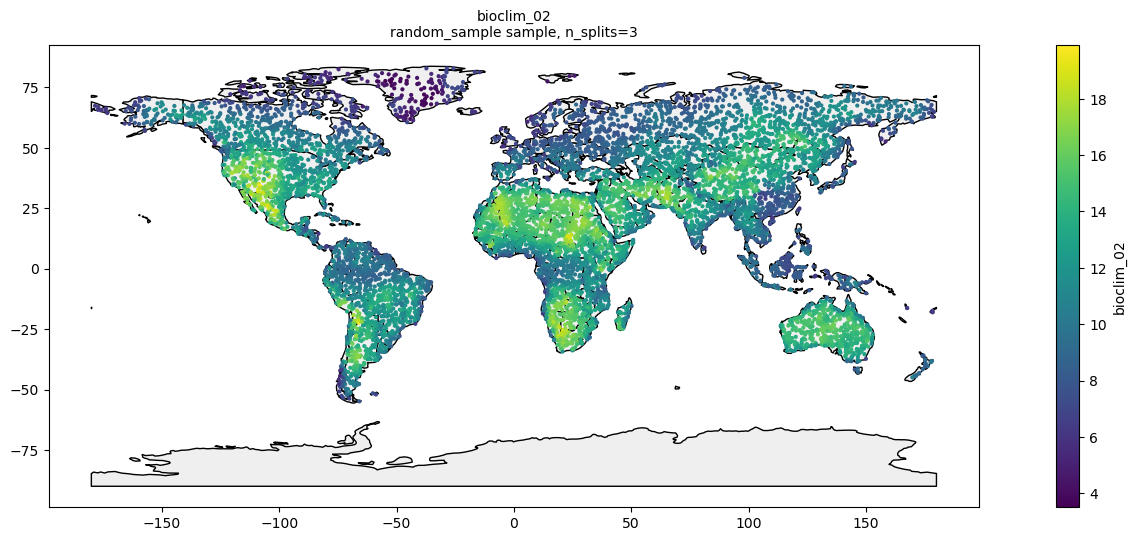

In [84]:
plot_mod = 'bioclim_02'
sample_type = 'random_sample'

assert plot_mod in df_all.columns
gdf_tmp = gpd.GeoDataFrame(gdf_tmp, geometry=gpd.points_from_xy(gdf_tmp['lon'], gdf_tmp['lat']), crs='EPSG:4326')
fig, ax = plt.subplots(figsize=(20,6))
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
gdf_tmp.plot(column=plot_mod, cmap='viridis', legend=True, markersize=4, ax=ax,
             legend_kwds={'label': f'{plot_mod}'})
plt.title(f'{plot_mod}\n{sample_type} sample, n_splits=3', fontsize=10)

Sample random_sample has 9695 data points out of 18393.
Sample lc_stratified_sample has 9693 data points out of 18393.


Text(0.5, 1.0, 'Difference in MSE of linear regression between alphaearth and all_geospatial\nlc_stratified_sample sample, n_splits=3, equal ambient dim: False\n Spearman r diff MSE with AE dim: -0.11 (2-sided p-value: 1.33e-26)')

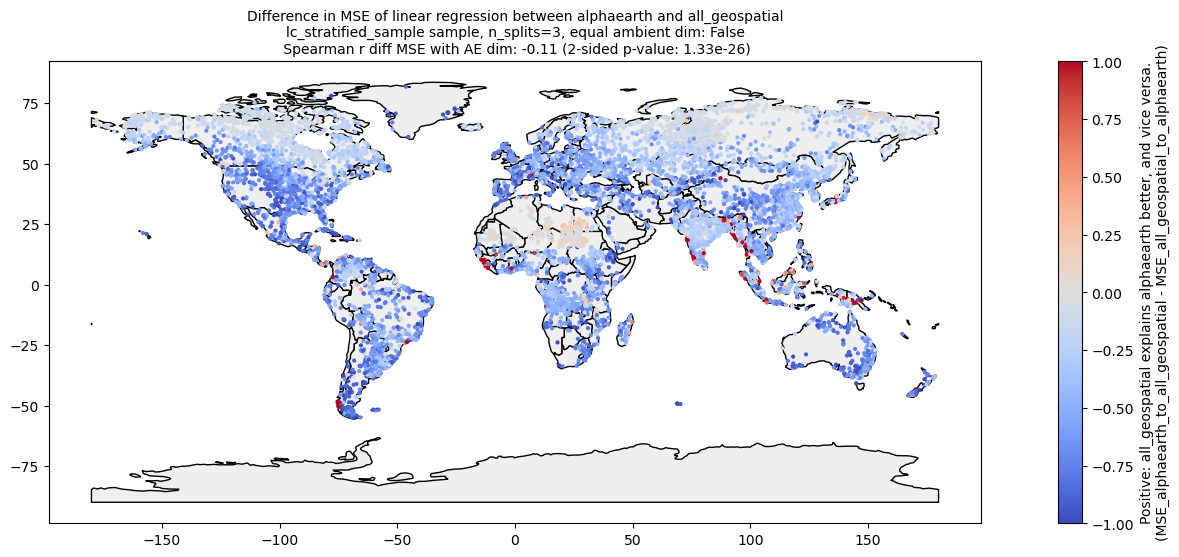

In [146]:
pair = ['alphaearth', 'all_geospatial']
n_splits = 3
equalize_ambient_dim = False
sample_type = 'lc_stratified_sample'

df_all, col_names = du.merge_modalities(parent_folder=data_folder, sample_type=sample_type, zscore_embeddings=True) 
_, gdf_1, __ = get_r2_regression(df_all, col_names, pair[0], pair[1], n_splits=n_splits, equalize_ambient_dim=equalize_ambient_dim)
gdf_1 = gpd.GeoDataFrame(gdf_1, geometry=gpd.points_from_xy(gdf_1['lon'], gdf_1['lat']), crs='EPSG:4326')
_, gdf_2, __ = get_r2_regression(df_all, col_names, pair[1], pair[0], n_splits=n_splits, equalize_ambient_dim=equalize_ambient_dim)
gdf_2 = gpd.GeoDataFrame(gdf_2, geometry=gpd.points_from_xy(gdf_2['lon'], gdf_2['lat']), crs='EPSG:4326')

## If positive, the 0->1 error is higher than the 1->0 error, and vice versa if negative.
## Hence, if positive, it means that 1 is better at predicting 0 than the other way around.
gdf_1[f'diff_mse_{pair[0]}_{pair[1]}'] = gdf_1[f'{pair[0]}_to_{pair[1]}_mse'] - gdf_2[f'{pair[1]}_to_{pair[0]}_mse']
# gdf_1['ae_dim'] = array_dim

# corr_dim_diff_mse = np.corrcoef(gdf_1['ae_dim'], gdf_1[f'diff_mse_{pair[0]}_{pair[1]}'])[0, 1]
# from scipy.stats import spearmanr
# corr_dim_diff_mse, pval = spearmanr(gdf_1['ae_dim'], gdf_1[f'diff_mse_{pair[0]}_{pair[1]}'])

fig, ax = plt.subplots(figsize=(20,6))
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
# lim = np.max(np.abs(gdf_1[f'diff_mse_{pair[0]}_{pair[1]}']))
gdf_1.plot(column=f'diff_mse_{pair[0]}_{pair[1]}', cmap='coolwarm', 
            legend=True, markersize=4, ax=ax, 
            # vmin=-lim, vmax=lim,
            vmin=-1, vmax=1,
            legend_kwds={'label': f'Positive: {pair[1]} explains {pair[0]} better, and vice versa.' +
            f'\n(MSE_{pair[0]}_to_{pair[1]} - MSE_{pair[1]}_to_{pair[0]})'})
plt.title(f'Difference in MSE of linear regression between {pair[0]} and {pair[1]}\n{sample_type} sample, n_splits={n_splits}, equal ambient dim: {equalize_ambient_dim}\n Spearman r diff MSE with AE dim: {corr_dim_diff_mse:.2f} (2-sided p-value: {pval:.2e})', fontsize=10)

## Next:
- Dim per AE/T patch, plot per point. Does any of the emb->emb performance correlate with dim (eg low dim in sahara)


In [130]:
def get_dim(im):
    assert im.shape[0] > im.shape[1], f'Number of samples {im.shape[0]} should be greater than number of features {im.shape[1]} for PCA to work properly.'
    pca = PCA(n_components=im.shape[1])
    pca.fit(im)
    sum_squares = np.sum(np.power(pca.explained_variance_, 2))
    square_sum = np.sum(pca.explained_variance_) ** 2
    dim = float(square_sum / sum_squares)
    return dim, pca

def get_list_dims(parent_folder=data_folder, sample_type='lc_stratified_sample', modality='alphaearth'):
    list_ids, modality_folders, gdf_points = du.get_list_complete_ids(parent_folder)
    if modality == 'alphaearth':
        suffix = '_alphaearth_y-2024.tif'
    else:
        raise ValueError(f'Modality {modality} not supported.')
    dict_results = {x: [] for x in ['id', 'dim']}
    for id_patch in tqdm(list_ids):
        path_modality = os.path.join(modality_folders[modality], f'{id_patch}{suffix}')
        if os.path.exists(path_modality):
            im = du.load_tiff(path_modality, datatype='np')
            im = im.reshape(im.shape[0], -1).T
            dim, _ = get_dim(im)

            dict_results['id'].append(int(id_patch))
            dict_results['dim'].append(dim)
    return dict_results


# tmp = get_list_dims()

Text(0.5, 1.0, 'AlphaEarth dimensionality, random_sample sample')

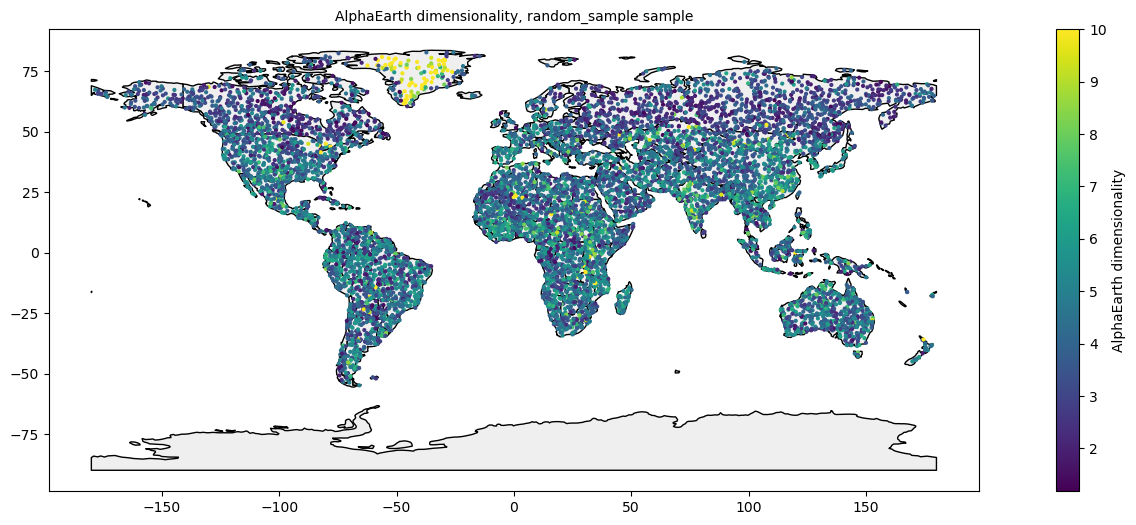

In [104]:
df_dim = pd.DataFrame(tmp)
array_dim = np.array([df_dim[df_dim['id'] == id_patch]['dim'].values[0] for id_patch in gdf_1.id])
gdf_1['ae_dim'] = array_dim
gdf_1['ae_dim_log'] = np.log(array_dim)

fig, ax = plt.subplots(figsize=(20,6))
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
gdf_1.plot(column=f'ae_dim', cmap='viridis', legend=True, markersize=4, ax=ax,
             legend_kwds={'label': f'AlphaEarth dimensionality'}, vmax=10)
plt.title(f'AlphaEarth dimensionality, {sample_type} sample', fontsize=10)

In [132]:
np.corrcoef(gdf_1.ae_dim, gdf_1.diff_mse_alphaearth_geoclip)

array([[ 1.        , -0.11570172],
       [-0.11570172,  1.        ]])